In [1]:
# Import necessary libraries for data analysis, visualization, and machine learning

# Data manipulation and numerical computations
import numpy as np
import pandas as pd

# Plotting and visualization
import matplotlib as mpl
import matplotlib.pyplot as plt

# Scientific computing and statistics
from scipy.optimize import curve_fit
from scipy.stats import f_oneway
import time
from itertools import combinations

# Machine learning classifiers and metrics
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, brier_score_loss

# Custom functions for MLACCA (Machine Learning-Assisted Compound Class Assignment)
import mlacca_functions as mlcf

from warnings import filterwarnings
# Suppress expected sklearn UserWarnings when using different class definitions
filterwarnings("ignore", module="sklearn", category=UserWarning)
# Suppress expected RuntimeWarnings from np.nanmean when calculating class-wise accuracies with all NaN values
filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Configuration settings and file paths

# Path to the dataset containing van Krevelen area assignments
df_path = 'data\\csv_files\\new_vk_areas_df.csv'

# Output folder for comparison plots and CSV files
comparison_plots_output_folder = 'data\\plots\\comparisons'
csv_folder = 'data\\csv_files'

# Model configuration flags
weighted = True  # Whether to use class weights to handle imbalanced datasets
show_title = False  # Whether to display titles on plots (False for publication-ready figures)

In [3]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv(df_path)

In [4]:
# Custom utility functions for model evaluation and visualization

def test_model_accuracy(model, X, y, repeats=50, classifier_name='[DEFAULT]', title=None,
                        xlabel=None, ylabel=None, colors_dict=None):
    """
    Test a machine learning model's accuracy over multiple random train-test splits.
    
    Parameters:
    -----------
    model : sklearn classifier
        The model to test
    X : array-like
        Feature matrix
    y : array-like
        Target labels
    repeats : int
        Number of random train-test splits to perform
    classifier_name : str
        Name of the classifier for reporting
    title, xlabel, ylabel : str, optional
        Plot labels (only used for 2D feature spaces)
    colors_dict : dict, optional
        Color mapping for categories in decision boundary plot
    
    Returns:
    --------
    Prints accuracy statistics and optionally creates decision boundary plot (for 2D data)
    """
    accuracies = []

    # Repeat training and testing with random splits
    for i in range(repeats):
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X, y, random_state=None)

        # Fit model with sample weights if weighted mode is enabled
        fitted_model = model.fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)

        # Calculate balanced accuracy score
        accuracies.append(balanced_accuracy_score(y_true=y_rdm_test,
                                                  y_pred=fitted_model.predict(X_rdm_test),
                                                  sample_weight=weights_rdm_test if weighted else None))

        # Keep track of the best performing model for visualization
        if accuracies[i] == np.max(accuracies):
            max_model = fitted_model
            X_rdm_train_best = X_rdm_train
            y_rdm_train_best = y_rdm_train

    # Print summary statistics
    print(f'''Average accuracy of the {classifier_name} classifier trained on {len(X_rdm_train)} samples (run {repeats} times): {np.mean(accuracies)} +/- {np.std(accuracies)}
Max accuracy: {np.max(accuracies)}
Min accuracy: {np.min(accuracies)}
Random Accuracy: {1/len(np.unique(y_rdm_train))}''')

    # Create decision boundary plot for 2D feature spaces
    if np.shape(X)[1] == 2:
        mlcf.draw_decision_boundary_plot(max_model,
                                    X_rdm_train_best,
                                    categories=np.unique(y_rdm_train_best),
                                    xlabel=xlabel,
                                    ylabel=ylabel,
                                    colors_dict=colors_dict,
                                    title=title)


def fitting_runtime(iterations: int, model, X, y, weights) -> float:
    """
    Measure the average runtime for fitting a model.
    
    Parameters:
    -----------
    iterations : int
        Number of times to fit the model
    model : sklearn classifier
        The model to benchmark
    X, y : array-like
        Training data and labels
    weights : array-like
        Sample weights
    
    Returns:
    --------
    float : Average fitting time in seconds
    """
    times = []

    for i in range(iterations):
        start_time = time.time()
        fit = model.fit(X, y, sample_weight=weights)
        runtime = time.time() - start_time
        times.append(runtime)

    return sum(times) / iterations


def draw_violinplot(data_dict, ylabel, title=None, savepath=None, colours=[],
                    hline=None, xlabel_rotation=45, ha='right', figsize=(6.4, 4.8)):
    """
    Create a violin plot to visualize the distribution of data.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary where keys are labels and values are data arrays
    ylabel : str
        Y-axis label
    title : str, optional
        Plot title
    savepath : str, optional
        Path to save the figure
    colours : list, optional
        Colors for each violin plot
    hline : float or list, optional
        Horizontal reference line(s) to draw
    xlabel_rotation : int
        Rotation angle for x-axis labels
    ha : str
        Horizontal alignment for x-axis labels
    figsize : tuple
        Figure size (width, height)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    labels = list(data_dict.keys())
    data = list(data_dict.values())

    fig, ax = plt.subplots(figsize=figsize)

    # Create violin plots without default decorations
    parts = ax.violinplot(data,
                          showmeans=False, showmedians=False,
                          showextrema=False)

    # Apply custom colors to violin plots
    if len(colours) > 0:
        if len(colours) == 1:
            colours = colours * len(labels)
        assert len(colours) == len(labels), "Number of colours must match number of violin plots"
        for pc, c in zip(parts['bodies'], colours):
            pc.set_facecolor(c)
            pc.set_edgecolor('black')
            pc.set_alpha(1)

    # Calculate and display quartiles
    quartile1, medians, quartile3 = np.percentile(np.array(data), [25, 50, 75], axis=1)

    inds = np.arange(1, len(medians) + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    # Format axes
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xticks(np.arange(1, len(labels) + 1), labels, rotation=xlabel_rotation, ha=ha, fontsize=12)

    # Add horizontal reference lines if specified
    if hline:
        if type(hline) in [list, tuple]:
            for hl in hline:
                ax.axhline(y=hl, color='r', linestyle='--', lw=1)
        else:
            ax.axhline(y=hline, color='r', linestyle='--', lw=1)

    if title:
        ax.set_title(title, fontsize=14)
    if savepath:
        fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def correlation_matrix(data_dict, threshold=0.05, savepath=None, title=None,
                       colours=['tab:orange', 'tab:blue']):
    """
    Create a correlation matrix showing statistical significance between model performances.
    
    Uses one-way ANOVA to test for significant differences between groups.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary where keys are model names and values are accuracy arrays
    threshold : float
        p-value threshold for statistical significance (default: 0.05)
    savepath : str, optional
        Path to save the figure
    title : str, optional
        Plot title
    colours : list
        Two colors: [significant difference, not significant difference]
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis objects
    """
    labels = list(data_dict.keys())

    # Calculate p-values for all pairwise comparisons using ANOVA
    p_dict = {}
    for comb in list(combinations(labels, 2)):
        p_dict[f'{comb[0]},{comb[1]}'] = f_oneway(*[data_dict[comb[0]], data_dict[comb[1]]], nan_policy='omit')[1]

    # Create binary correlation matrix (significant vs not significant)
    p_matrix = pd.DataFrame(np.ones((len(labels), len(labels))), index=labels, columns=labels)
    p_matrix[p_matrix == 1] = np.nan
    for comb in list(combinations(labels, 2)):
        p_value = p_dict[f'{comb[0]},{comb[1]}']
        p_matrix.loc[comb[0], comb[1]] = np.nan
        p_matrix.loc[comb[1], comb[0]] = p_value

    # Convert to binary: 1 for not significant, 0 for significant
    p_matrix[(p_matrix > threshold) & (p_matrix.notna())] = 1
    p_matrix[(p_matrix <= threshold) & (p_matrix.notna())] = 0

    fig, ax = plt.subplots()

    # Create custom colormap
    cmap = mpl.colors.ListedColormap(colours)
    cax = ax.matshow(p_matrix, cmap=cmap)

    # Add legend
    for label, colour in zip([f'$p\\leq{threshold}$', f'$p>{threshold}$'], colours):
        ax.scatter(None, None, c=colour, label=label, marker='s', s=100)

    ax.legend(framealpha=1, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)

    # Format axes
    ax.set_xticks(np.arange(len(labels) - 1), labels[:-1], rotation=45, horizontalalignment='right')
    ax.set_yticks(np.arange(1, len(labels)), labels[1:])
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlim(-0.5, len(labels) - 1.5)
    ax.set_ylim(len(labels) - 0.5, 0.5)

    if title:
        ax.set_title(title, fontsize=14)
    if savepath:
        fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def set_y_ticks(data_dict, ax, major_ticks_interval=0.1, minor_ticks_interval=0.05, rounding=2):
    """
    Set y-axis tick marks with automatic limits based on data range.
    
    Parameters:
    -----------
    data_dict : dict
        Data dictionary to determine axis limits
    ax : matplotlib axis
        Axis object to modify
    major_ticks_interval : float
        Spacing for major tick marks
    minor_ticks_interval : float
        Spacing for minor tick marks
    rounding : int
        Decimal places for rounding the lower limit
    """
    # Calculate y-axis limits based on data minimum
    rounded_min = np.round(np.min(list(data_dict.values())))
    rounded_min = rounded_min - (rounded_min % major_ticks_interval)
    # rounded_max = np.round(np.min(list(data_dict.values())))
    # rounded_max = rounded_min - (rounded_min % major_ticks_interval) + major_ticks_interval

    ylim = (rounded_min, 100)
    ax.set_ylim(ylim)
    
    # Set major and minor tick marks
    ax.set_yticks(np.arange(np.round(np.floor(1e2 * ylim[0]) / 1e2, 1), ylim[1] + 1e-2, major_ticks_interval))
    ax.tick_params(axis='y', which='minor')
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(minor_ticks_interval))

In [5]:
rounding = 0
data_dict = {
    'Model A': [85, 87, 90, 88, 86],
    'Model B': [80, 82, 78, 81, 79]
}

major_ticks_interval = 5

# ylim = (np.round(np.floor(10**rounding * np.min(list(data_dict.values()))) / 10**rounding, rounding) - 10**-rounding, 100)
rounded_min = np.round(np.min(list(data_dict.values())))
rounded_min = rounded_min - (rounded_min % major_ticks_interval)
ylim = (rounded_min, 100)
ylim
# np.arange(np.round(np.floor(1e2 * ylim[0]) / 1e2, rounding), ylim[1] + 1e-2, major_ticks_interval)

(np.int64(75), 100)

In [6]:
# Define feature sets for different dimensionalities of van Krevelen space

# 2D van Krevelen diagram (commonly used in literature)
columns_2d = ['O/C', 'H/C']

# 3D extended van Krevelen space (includes N/C)
columns_3d = ['O/C', 'H/C', 'N/C']
X_3d = df[columns_3d].copy().to_numpy()

# Multi-dimensional feature space (includes P/C and N/P ratios)
columns_multi = ['O/C', 'H/C', 'N/C', 'P/C', 'N/P']

# True compound class assignments
y = df['category'].copy().to_numpy()

# Sample weights for handling class imbalance (if weighted mode is enabled)
weights = df['weights'].copy().to_numpy() if weighted else None

# Create Rivas-Ubach categories (merge tannin and lignin into phytochemical)
y_ru = df['category'].copy().to_numpy()
y_ru[[x in ['tannin', 'lignin'] for x in y_ru]] = 'phytochemical'

# Compute class weights for Rivas-Ubach categories
class_weights_ru = compute_class_weight('balanced', classes=np.unique(y_ru), y=y_ru)
weights_dict_ru = {cls: weight for cls, weight in zip(np.unique(y_ru), class_weights_ru)}
weights_ru = [weights_dict_ru[cat] for cat in y_ru]

# Color scheme for each category in multi-class plots
multiclass_colors = [mlcf.vk_region_colours[cat] for cat in np.unique(y)]

In [7]:
# Comparison of Literature models

In [8]:
# Compare accuracy of literature-based classification models

lit_acc_comparison = {'lit_model': [], 'accuracy': [], 'balanced_accuracy': []}

# Test each literature model and baseline
for combo in [['Zero rule', y],  # Baseline: predict most frequent class
              ['DBCCR', mlcf.laszakovits_mackay_areas, columns_2d, y],  # Laszakovits & MacKay 2D model
              ['3D Hybrid', mlcf.ru_lm_areas, columns_3d, y],  # Rivas-Ubach & Laszakovits-MacKay 3D model
              ['Hybrid (complete)', mlcf.ru_lm_areas_complete, columns_multi, y],  # Full multi-dimensional
              # Rivas-Ubach definitions (with merged phytochemical category):
              ['Zero rule (R-U)', y_ru],
              ['3D MSCC (R-U)', mlcf.rivasubach_areas, columns_3d, y_ru],
              ['MSCC (R-U)', mlcf.rivasubach_areas_complete, columns_multi, y_ru],
              ]:

    lit_acc_comparison['lit_model'].append(combo[0])

    # Generate predictions: use molecclass for literature models, most frequent class for zero rule
    y_pred = mlcf.molecclass(df, combo[1], combo[2]) if 'Zero rule' not in combo[0] \
            else [np.unique(combo[-1])[np.argmax([len(np.where(combo[-1] == cat)[0]) for cat in np.unique(combo[-1])])]] * len(combo[-1])
 
    # Calculate both standard and balanced accuracy
    for combo2 in [['accuracy', accuracy_score, dict(normalize=True)],
                   ['balanced_accuracy', balanced_accuracy_score, dict(sample_weight=weights if weighted else None)]]:
        
        lit_acc_comparison[combo2[0]].append(combo2[1](y_true=combo[-1],
                                                       y_pred=y_pred,
                                                       **combo2[2]))

# Save results to CSV
lit_acc_comparison_df = pd.DataFrame(lit_acc_comparison)
lit_acc_comparison_df.to_csv(f'{csv_folder}\\lit_model_comparison.csv', index=False)
lit_acc_comparison_df

,lit_model,accuracy,balanced_accuracy
0,Zero rule,0.852779,0.166667
1,DBCCR,0.734101,0.597914
2,3D Hybrid,0.884160,0.775316
3,Hybrid (complete),0.349190,0.335455
4,Zero rule (R-U),0.852779,0.200000
5,3D MSCC (R-U),0.902187,0.843342
6,MSCC (R-U),0.349190,0.402546


In [9]:
# comparison of MLACCA models with literature models

In [10]:
# Define all models to be compared: literature models and machine learning classifiers

# Weighted supervised classifiers (use class weights)
clf_models = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),  # Gaussian Naive Bayes with probability calibration
    'Poly SVM (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d)),  # Polynomial kernel SVM
    'RBF SVM (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d)),  # RBF kernel SVM
}

# Unweighted supervised classifiers (no class weights)
clf_models_unweighted = {x.replace('(W)', '(U)'): clf_models[x] for x in clf_models}
clf_models_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d)  # K-Nearest Neighbors

# Literature-based classification models
lit_models = {
    'DBCCR': mlcf.laszakovits_mackay_areas,  # Data-Based Compound Class Region
    'Hybrid': mlcf.ru_lm_areas,  # Multidimensional Stoichiometric Compound Classification
}

# Same models but for Rivas-Ubach category definitions
phyto_clf_models = {f'{x} (R-U)': clf_models[x] for x in clf_models}
phyto_clf_models_unweighted = {f'{x} (R-U)': clf_models_unweighted[x] for x in clf_models_unweighted}
phyto_lit_model = {'3D MSCC': mlcf.rivasubach_areas}

non_phytos = list(lit_models.keys()) + list(clf_models_unweighted.keys()) + list(clf_models.keys())
phytos = list(phyto_lit_model.keys()) + list(phyto_clf_models_unweighted.keys()) + list(phyto_clf_models.keys())

# Complete list of all models to test
models_list = non_phytos + phytos

In [11]:
# Comprehensive model comparison across multiple random train-test splits
# This provides robust statistical evaluation of model performance

# Initialize dictionaries to store accuracy metrics
accuracies_dict = {name: [] for name in models_list}
balanced_accuracies_dict = {name: [] for name in models_list}
zero_rule_acc = []  # Baseline accuracy from predicting most frequent class

repeats = 40  # Number of random train-test splits

# Organize models by category definition (standard vs Rivas-Ubach)
iteration_dict = {'non_r-u': {'definition': y, 'modeltypes': [clf_models, clf_models_unweighted, lit_models]},
                  'r-u': {'definition': y_ru, 'modeltypes': [phyto_clf_models, phyto_clf_models_unweighted, phyto_lit_model]}}

# Store class-wise accuracies for each model
all_classes = np.unique(np.concatenate((y, y_ru)))
accuracy_by_class = {model: {class_: [] for class_ in all_classes} for model in models_list}

# Main evaluation loop
for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')
    
    # Test models with both category definitions
    for definition_type in iteration_dict:
        # Create random train-test split
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X_3d, iteration_dict[definition_type]['definition'], random_state=None)

        # Calculate zero rule baseline (for standard definitions only)
        if definition_type == 'non_r-u':
            zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test == cat)[0]) for cat in np.unique(y_rdm_test)])]
            zero_rule_acc.append(100 * accuracy_score(y_true=y_rdm_test,
                                                      y_pred=[zero_rule_class] * len(y_rdm_test),
                                                      normalize=True))

        # Test each model type (weighted classifiers, unweighted classifiers, literature models)
        for modeltype in iteration_dict[definition_type]['modeltypes']:

            for model in modeltype:
                
                print(f'{n+1}/{repeats}\tTesting model: {model}')

                # Prepare fit arguments (add sample weights for weighted classifiers)
                fit_args = dict(X=X_rdm_train, y=y_rdm_train)
                if weighted and modeltype in [clf_models, phyto_clf_models]:
                    fit_args['sample_weight'] = weights_rdm_train

                # Fit classifier or use literature model
                clf = modeltype[model].fit(**fit_args) if modeltype not in [lit_models, phyto_lit_model] else None

                # Generate predictions
                y_pred = clf.predict(X_rdm_test) if modeltype not in [lit_models, phyto_lit_model] \
                         else mlcf.molecclass(pd.DataFrame(X_rdm_test, columns=columns_3d),
                                              areas=lit_models[model] if modeltype == lit_models else phyto_lit_model[model],
                                              dims=columns_3d if 'DBCCR' not in model else columns_2d)

                # Calculate both accuracy and balanced accuracy
                for accuracy_type in [[accuracy_score, dict(normalize=True), accuracies_dict],
                                      [balanced_accuracy_score, dict(sample_weight=weights_rdm_test if weighted else None), balanced_accuracies_dict]]:
                    
                    acc = accuracy_type[0](y_true=y_rdm_test,
                                           y_pred=y_pred,
                                           **accuracy_type[1])
                    accuracy_type[2][model].append(acc*100)

                print(f'\t\taccuracy: {accuracies_dict[model][-1]}, balanced accuracy: {balanced_accuracies_dict[model][-1]}')

                # Store class-wise accuracies
                class_acc_dict = mlcf.class_wise_accuracy(y_true=y_rdm_test, y_pred=y_pred)
                for class_ in all_classes:
                    accuracy_by_class[model][class_].append(class_acc_dict[class_] * 100 if class_ in class_acc_dict else np.nan)


Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 77.98165137614679, balanced accuracy: 88.51703498762329
1/40	Testing model: Poly SVM (W)
		accuracy: 88.65721434528774, balanced accuracy: 93.66691749044695
1/40	Testing model: RBF SVM (W)
		accuracy: 89.49124270225187, balanced accuracy: 92.25193107546052
1/40	Testing model: GNB (U)
		accuracy: 91.65971643035863, balanced accuracy: 63.448536389712864
1/40	Testing model: Poly SVM (U)
		accuracy: 94.4954128440367, balanced accuracy: 72.69837446308036
1/40	Testing model: RBF SVM (U)
		accuracy: 95.41284403669725, balanced accuracy: 77.94556588674236
1/40	Testing model: KNN
		accuracy: 96.08006672226855, balanced accuracy: 89.57854340207282
1/40	Testing model: DBCCR
		accuracy: 73.31109257714762, balanced accuracy: 56.724067459361635
1/40	Testing model: Hybrid
		accuracy: 88.74061718098415, balanced accuracy: 76.63695207812857
1/40	Testing model: GNB (W) (R-U)
		accuracy: 78.23185988323603, balanced accuracy: 92.54500

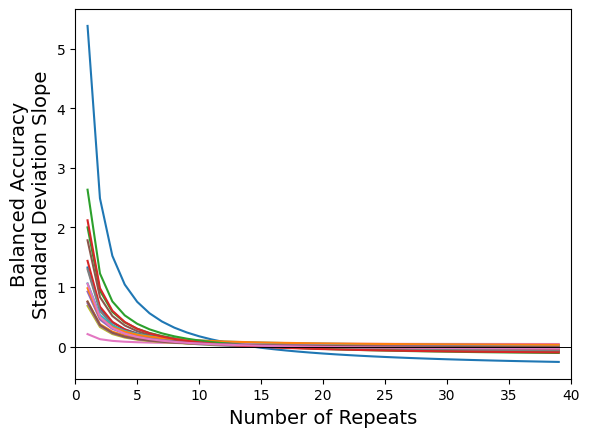

In [12]:
# Analyze convergence of standard deviation with increasing repeats
# This helps determine if the number of repeats (40) is sufficient

SAVE = True  # Whether to save plots

def fitting_func(x, a, c):
    """Hyperbolic function to fit balanced accuracy std deviation slope decay: y = c + a/x"""
    return (a / x) + c

curves_list = []

# Analyze each model individually
for model in models_list:
    fig, ax = plt.subplots()

    n_of_times = range(1, len(balanced_accuracies_dict[model]) + 1)

    # Calculate standard deviation at each step
    step_wise_stds = [np.std(balanced_accuracies_dict[model][:i]) for i in n_of_times]

    # Calculate slope (rate of change) of standard deviation
    y_axis = np.diff(step_wise_stds) / np.diff(n_of_times)

    ax.scatter(n_of_times[:-1], y_axis, marker='.', alpha=0.7)

    # Fit hyperbolic decay curve
    popt, pcov = curve_fit(fitting_func, n_of_times[:-1], y_axis)
    curves_list.append(fitting_func(np.array(n_of_times[:-1]), *popt))
    ax.plot(n_of_times[:-1], curves_list[-1], 'r--', label=f'$y={popt[1]:.4f}+\\frac{{{popt[0]:.4f}}}{{x}}$')
    ax.legend(fontsize=14)

    if show_title:
        ax.set_title(f'{model}\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
    ax.set_xlabel('Number of Repeats', fontsize=14)
    ax.set_ylabel('Balanced Accuracy\nStandard Deviation Slope', fontsize=14)
    ax.set_xlim(0, len(balanced_accuracies_dict[model]))

    ax.axhline(0, lw=.7, c='k')  # Reference line at zero slope

    if SAVE:
        fig.savefig(f'{comparison_plots_output_folder}\\accuracy_std_vs_repeats\\balanced_accuracy_std_slope_vs_repeats_{model.replace(" ", "_")}.png',
                    dpi=600, facecolor='#fff', bbox_inches='tight')

    plt.close()

# Create combined plot showing all models
fig, ax = plt.subplots()
for curve in curves_list:
    ax.plot(range(1, len(balanced_accuracies_dict[model])), curve)
if show_title:
    ax.set_title(f'All Models\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
ax.set_xlabel('Number of Repeats', fontsize=14)
ax.set_ylabel('Balanced Accuracy\nStandard Deviation Slope', fontsize=14)
ax.set_xlim(0, len(balanced_accuracies_dict[model]))
ax.axhline(0, lw=.7, c='k')
if SAVE:
    fig.savefig(f'{comparison_plots_output_folder}\\accuracy_std_vs_repeats\\balanced_accuracy_std_slope_vs_repeats_all_models.png',
                dpi=600, facecolor='#fff', bbox_inches='tight')

In [13]:
# Adjust balanced accuracies to account for chance-level performance
# Formula: adjusted = (acc - chance) / (1 - chance)
# This scales accuracy so that 0 = chance level, 1 = perfect prediction

chance_balanced_accuracies_dict = {}

for key in balanced_accuracies_dict:
    # Determine number of categories for this model
    number_of_categories = len(np.unique(y)) if key not in list(phyto_lit_model.keys()) + list(phyto_clf_models.keys()) \
                          else len(np.unique(y_ru))

    chance = 1 / number_of_categories  # Random guessing baseline

    # Apply adjustment formula
    chance_balanced_accuracies_dict[key] = [(acc - chance*100) / (1 - chance) for acc in balanced_accuracies_dict[key]]

In [14]:
# Summarize model performance statistics and save to CSV

comparison_df = pd.DataFrame({
    'model': [model.replace('$', '').replace('\\', '') for model in models_list],
    # Standard accuracy statistics
    'mean_accuracy': [np.mean(accuracies_dict[model]) for model in models_list],
    'std_accuracy': [np.std(accuracies_dict[model]) for model in models_list],
    'median_accuracy': [np.median(accuracies_dict[model]) for model in models_list],
    # Balanced accuracy statistics (accounts for class imbalance)
    'mean_balanced_accuracy': [np.mean(balanced_accuracies_dict[model]) for model in models_list],
    'std_balanced_accuracy': [np.std(balanced_accuracies_dict[model]) for model in models_list],
    'median_balanced_accuracy': [np.median(balanced_accuracies_dict[model]) for model in models_list],
    # Chance-adjusted balanced accuracy statistics
    'mean_chance_balanced_accuracy': [np.mean(chance_balanced_accuracies_dict[model]) for model in models_list],
    'std_chance_balanced_accuracy': [np.std(chance_balanced_accuracies_dict[model]) for model in models_list],
    'median_chance_balanced_accuracy': [np.median(chance_balanced_accuracies_dict[model]) for model in models_list],
})

comparison_df.to_csv(f'{csv_folder}\\model_performance_comparison.csv', index=False)
# comparison_df

In [15]:
# Summarise class-wise accuracies and save to CSV
class_wise_acc_df = pd.DataFrame(accuracy_by_class).T
for col in class_wise_acc_df.columns:

    for idx in class_wise_acc_df.index:
        class_wise_acc_df.loc[idx, col] = np.nanmean(accuracy_by_class[idx][col])

    class_wise_acc_df[f'{col}_std'] = [np.nanstd(accuracy_by_class[idx][col]) for idx in class_wise_acc_df.index]
    class_wise_acc_df[f'{col}_median'] = [np.nanmedian(accuracy_by_class[idx][col]) for idx in class_wise_acc_df.index]

# reorder the columns to have model first, then each class with its mean, std, and median
cols = np.array([[x, f'{x}_std', f'{x}_median'] for x in all_classes]).flatten().tolist()

class_wise_acc_df = class_wise_acc_df[cols]
class_wise_acc_df.to_csv(f'{csv_folder}\\class_wise_accuracy.csv', index_label='model') # keep index as model names
# class_wise_acc_df

In [16]:
# Summarise class-wise accuracies and save to CSV

class_wise_acc_df = pd.DataFrame({
    'model': accuracy_by_class.keys(),
    **{class_: [np.nanmean(accuracy_by_class[model][class_]) for model in accuracy_by_class] for class_ in all_classes},
    # add standard deviation and median for each class
    **{f'{class_}_std': [np.nanstd(accuracy_by_class[model][class_]) for model in accuracy_by_class] for class_ in all_classes},
    **{f'{class_}_median': [np.nanmedian(accuracy_by_class[model][class_]) for model in accuracy_by_class] for class_ in all_classes}
})

# reorder the columns to have model first, then each class with its mean, std, and median
cols = ['model'] + np.array([[x, f'{x}_std', f'{x}_median'] for x in all_classes]).flatten().tolist()

class_wise_acc_df = class_wise_acc_df[cols]

class_wise_acc_df.to_csv(f'{csv_folder}\\class_wise_accuracy.csv', index=False)
# class_wise_acc_df

In [17]:
# Define color scheme for visualizations

# Color mapping for different model categories
boxplot_colors_dict = {
    'Literature Models': 'gold',
    'Unweighted Supervised\nClassifier Models': 'lightcoral',
    'Weighted Supervised\nClassifier Models': 'skyblue',
}
zero_rule_colour = 'grey'  # Baseline model color

def model_colour(model):
    """Assign color to a model based on its type."""
    if '(W)' in model:
        return boxplot_colors_dict['Weighted Supervised\nClassifier Models']
    elif any([x in model for x in ['DBCCR', '3D MSCC', 'Hybrid']]):
        return boxplot_colors_dict['Literature Models']
    elif any([x in model for x in ['(U)', 'KNN']]):
        return boxplot_colors_dict['Unweighted Supervised\nClassifier Models']
    else:
        return zero_rule_colour

# Available plot types
plot_type = {
    'boxplot': mlcf.draw_boxplot,
    'violinplot': draw_violinplot
}

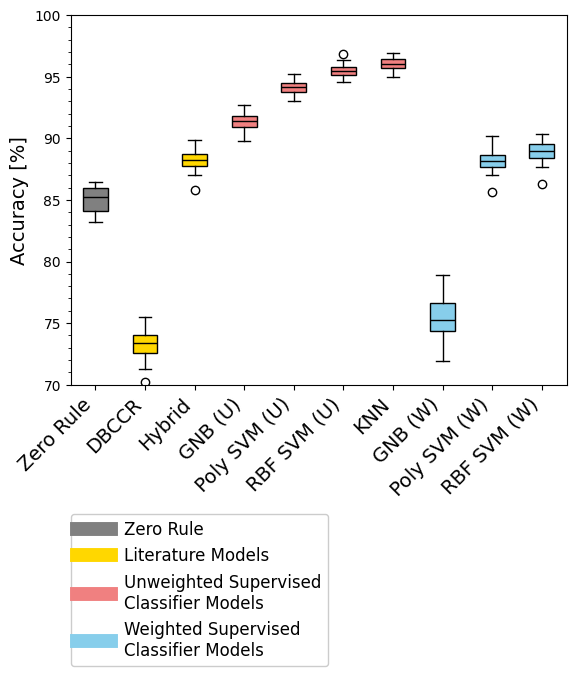

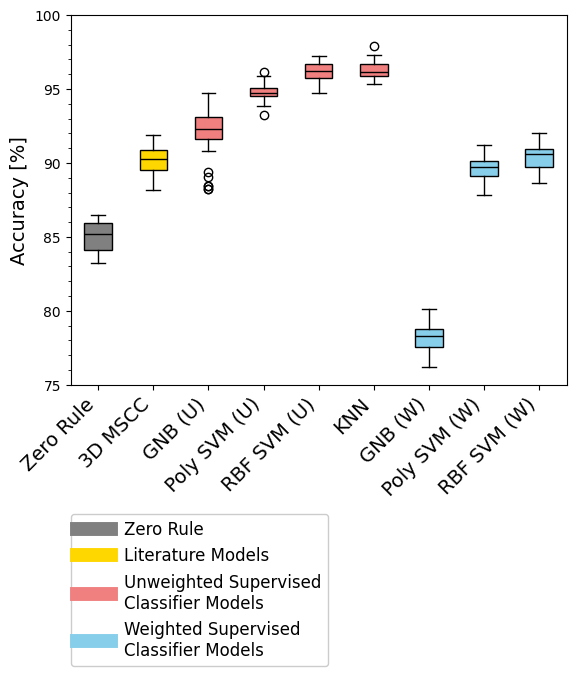

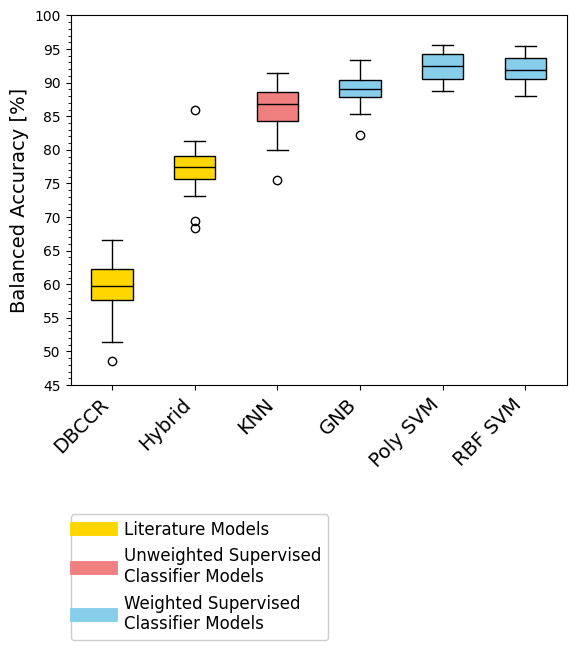

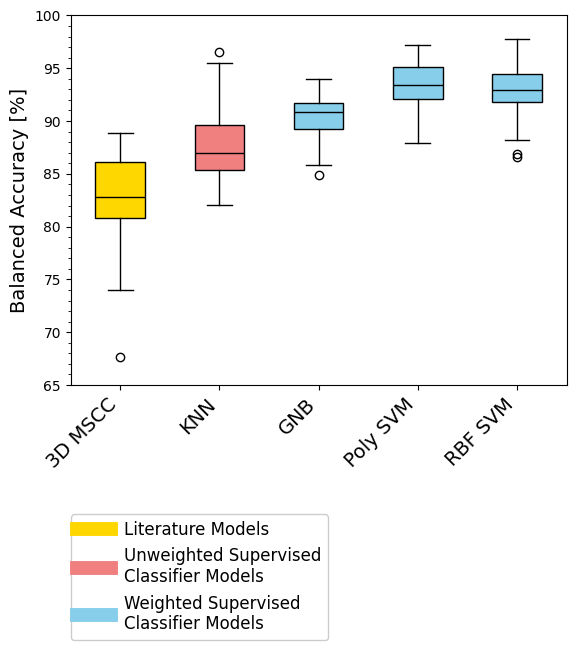

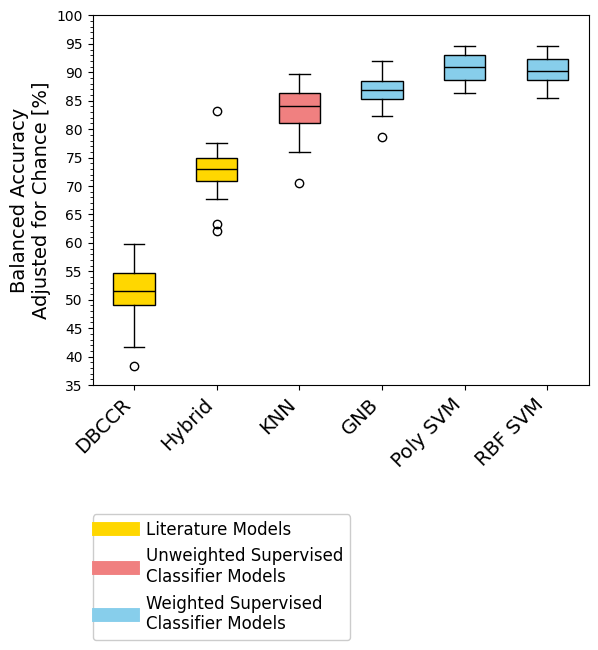

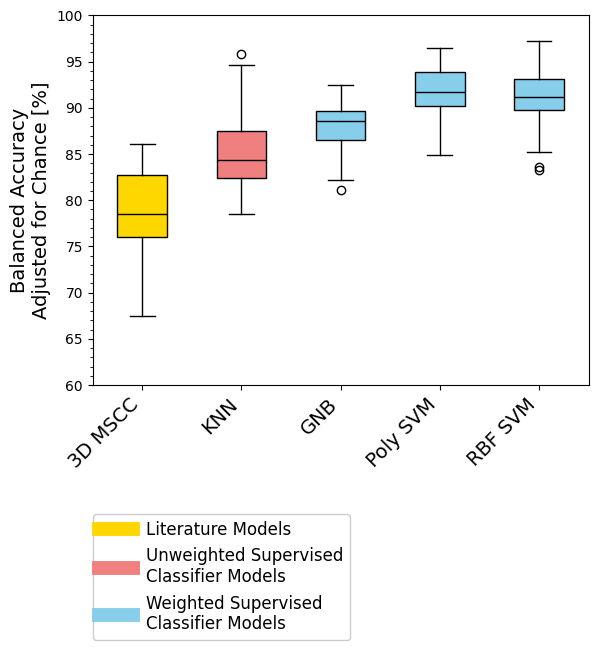

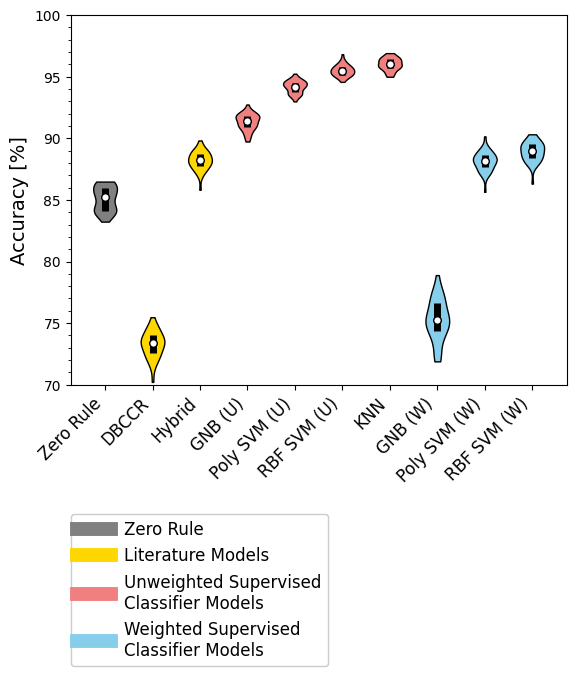

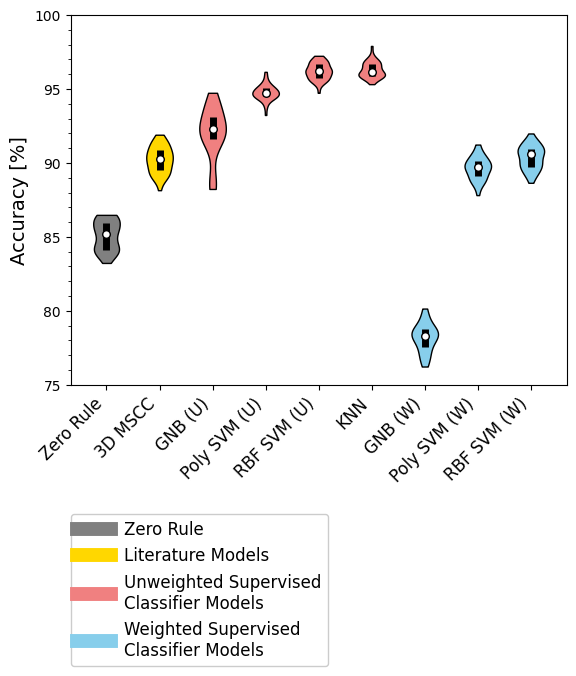

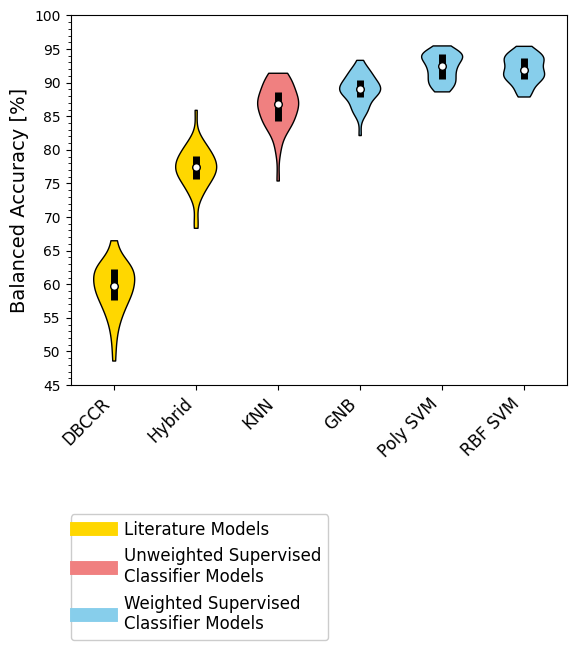

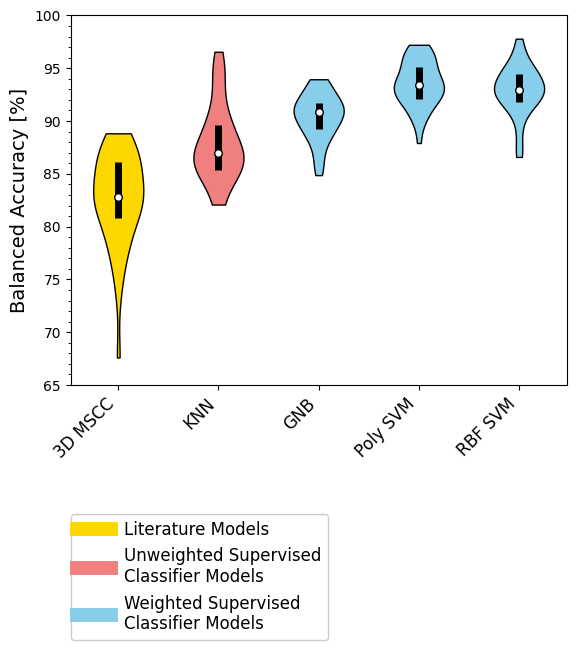

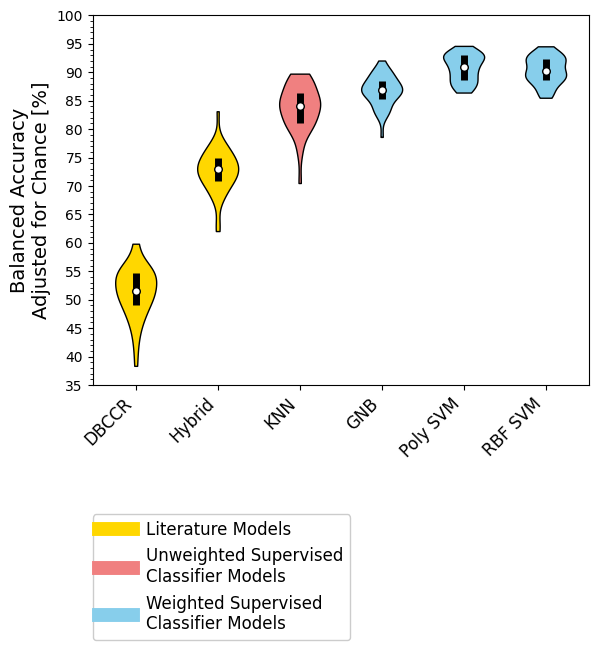

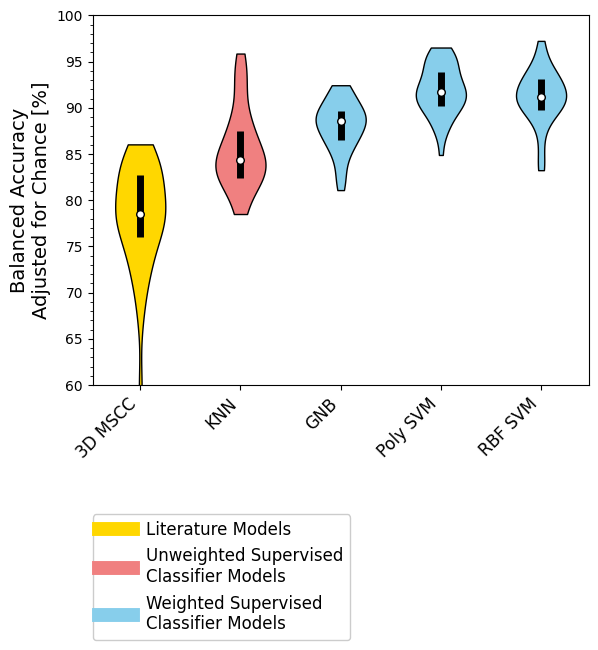

In [18]:
# Generate comprehensive comparison plots for all accuracy types

# Three types of accuracy metrics to visualize
data_dict = {
    'raw': accuracies_dict,  # Standard accuracy
    'balanced': balanced_accuracies_dict,  # Balanced accuracy (accounts for class imbalance)
    'chance': chance_balanced_accuracies_dict  # Chance-adjusted balanced accuracy
}

figsize = (10, 4.8)  # width, height in inches

def ru_bool(x):
    """Check if model uses Rivas-Ubach category definitions."""
    return 'R-U' in x or ('MSCC' in x and 'Adjusted' not in x)

hide_unweighted = True  # Option to simplify plots by hiding unweighted models

# Generate all combinations of plot types and accuracy metrics
for plot_choice in plot_type:
    for acc_type in data_dict.keys():
        
        # Set y-axis label based on accuracy type
        if acc_type == 'raw':
            ylabel = 'Accuracy'
            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_acc  # Include baseline
            for x in accuracies_dict:
                data_to_use[x] = accuracies_dict[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy'
            data_to_use = balanced_accuracies_dict
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict
        
        # Optionally hide unweighted models to simplify visualization
        if hide_unweighted and acc_type != 'raw':
            data_to_use = {x: data_to_use[x] for x in data_to_use if '(U)' not in x}

        # Create separate plots for standard and Rivas-Ubach definitions
        for ru_defs in [False, True]:

            if ru_defs:
                # Filter for Rivas-Ubach definition models
                data_to_use_ru = {x.replace(' (R-U)', ''): data_to_use[x] for x in data_to_use.keys() if ru_bool(x) or x == 'Zero Rule'}
            else:
                # Filter for standard definition models
                data_to_use_ru = {x: data_to_use[x] for x in data_to_use.keys() if not ru_bool(x)}

            # Assign colors based on model type
            boxplot_colors = [model_colour(x) for x in data_to_use_ru.keys()]

            # Simplify model names if hiding unweighted
            if acc_type != 'raw' and hide_unweighted:
                data_to_use_ru = {x.replace(' (W)', ''): data_to_use_ru[x] for x in data_to_use_ru}

            # Create the plot
            fig, ax = plot_type[plot_choice](data_to_use_ru,
                                             ylabel=f'{ylabel} [%]',
                                             colours=boxplot_colors)
            
            # Set appropriate y-axis limits and tick marks
            set_y_ticks(data_to_use_ru, ax, major_ticks_interval=5, minor_ticks_interval=1, rounding=0)

            # Add legend entries for model categories
            if acc_type == 'raw':
                ax.plot([None], [None], c=zero_rule_colour, label='Zero Rule', lw=10)

            for c in boxplot_colors_dict:
                if boxplot_colors_dict[c] in boxplot_colors:
                    ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)
            
            # Configure title and file path
            title = f'Comparison of the {ylabel.replace("\n", " ")} of Assignment\nbetween Literature and Classifier Models'
            fig_path = f'{comparison_plots_output_folder}\\acc_comparison_{plot_choice}_{acc_type}'
            if ru_defs:
                fig_path += '_rivas-ubach'
                title += '\n(R-U Definitions)'

            if show_title:
                ax.set_title(title, fontsize=16)

            # Position legend below plot
            ax.legend(framealpha=1, bbox_to_anchor=(0, -.35), loc='upper left', borderaxespad=0, fontsize=12)
            
            # Save as SVG for publication quality
            fig.savefig(f'{fig_path}.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

## Now fit models by adding another category: PAHs.

In [19]:
# Path to dataset that includes PAH (Polycyclic Aromatic Hydrocarbon) category
df_with_pahs_path = f'{csv_folder}\\new_vk_areas_with_pahs.csv'

In [20]:
# Load dataset with PAH category included
df_with_pahs = pd.read_csv(df_with_pahs_path)

In [21]:
# Prepare feature matrices and target variables for PAH-inclusive dataset

X_with_pahs_2d = df_with_pahs[columns_2d].copy().to_numpy()  # 2D features
X_with_pahs_3d = df_with_pahs[columns_3d].copy().to_numpy()  # 3D features

y_with_pahs = df_with_pahs['category'].copy().to_numpy()  # Target labels (including PAH)
weights_with_pahs = df_with_pahs['weights'].copy().to_numpy() if weighted else None  # Sample weights

In [22]:
# Define classifier models optimized for PAH-inclusive dataset
# Note: These use hyperparameters specifically tuned for the expanded category set

clf_models_with_pahs = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'Poly SVM (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d_with_PAHs)),
    'RBF SVM (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d_with_PAHs)),
}

# Create unweighted versions
clf_models_with_pahs_unweighted = {x.replace('(W)', '(U)'): clf_models_with_pahs[x] for x in clf_models_with_pahs}
clf_models_with_pahs_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d_with_PAHs)

models_with_pahs_list = list(clf_models_with_pahs_unweighted.keys()) + list(clf_models_with_pahs.keys())

In [23]:
# Evaluate model performance with PAH category included

# Initialize storage for accuracy metrics
accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
balanced_accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
zero_rule_with_pahs_acc = []

# Store class-wise accuracies for PAH-inclusive models
all_classes_with_pahs = np.unique(y_with_pahs)
accuracy_by_class_with_pahs = {model: {class_: [] for class_ in all_classes_with_pahs} for model in models_with_pahs_list}

repeats = 40

columns = columns_3d  # Use 3D feature space

# Main evaluation loop
for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')

    # Create random train-test split
    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = mlcf.train_test(X_with_pahs_3d, y_with_pahs, random_state=None)

    # Calculate zero rule baseline
    zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test == cat)[0]) for cat in np.unique(y_rdm_test)])]
    zero_rule_with_pahs_acc.append(100 * accuracy_score(y_true=y_rdm_test,
                                                        y_pred=[zero_rule_class] * len(y_rdm_test),
                                                        normalize=True))    

    # Test both weighted and unweighted classifier models
    for modeltype in [clf_models_with_pahs, clf_models_with_pahs_unweighted]:

        for model in modeltype:

            print(f'{n+1}/{repeats}\tTesting model: {model}')

            # Prepare fit arguments (add sample weights if using weighted model)
            fit_args = dict(X=X_rdm_train, y=y_rdm_train)
            if weighted and modeltype == clf_models_with_pahs:
                fit_args['sample_weight'] = weights_rdm_train

            # Fit model and generate predictions
            y_pred = modeltype[model].fit(**fit_args).predict(X_rdm_test)

            # Calculate both accuracy metrics
            for accuracy_type in [[accuracy_score, dict(normalize=True), accuracies_dict_with_pahs],
                                  [balanced_accuracy_score, dict(sample_weight=weights_rdm_test if weighted else None), balanced_accuracies_dict_with_pahs]]:

                acc = accuracy_type[0](y_true=y_rdm_test,
                                       y_pred=y_pred,
                                       **accuracy_type[1])
                accuracy_type[2][model].append(acc*100)

            print(f'\t\taccuracy: {accuracies_dict_with_pahs[model][-1]}, balanced accuracy: {balanced_accuracies_dict_with_pahs[model][-1]}')

            # Store class-wise accuracies
            class_acc_dict = mlcf.class_wise_accuracy(y_true=y_rdm_test, y_pred=y_pred)
            for class_ in all_classes_with_pahs:
                accuracy_by_class_with_pahs[model][class_].append(class_acc_dict[class_] * 100 if class_ in class_acc_dict else np.nan)

Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 75.24671052631578, balanced accuracy: 91.13698419067168
1/40	Testing model: Poly SVM (W)
		accuracy: 88.07565789473685, balanced accuracy: 94.15669330878352
1/40	Testing model: RBF SVM (W)
		accuracy: 89.39144736842105, balanced accuracy: 94.67349458090972
1/40	Testing model: GNB (U)
		accuracy: 91.5296052631579, balanced accuracy: 72.28692343154776
1/40	Testing model: Poly SVM (U)
		accuracy: 93.42105263157895, balanced accuracy: 64.5441500866991
1/40	Testing model: RBF SVM (U)
		accuracy: 96.13486842105263, balanced accuracy: 88.48041560014389
1/40	Testing model: KNN
		accuracy: 96.05263157894737, balanced accuracy: 87.6971603387976
Accuracy test iteration 2 of 40
2/40	Testing model: GNB (W)
		accuracy: 73.60197368421053, balanced accuracy: 87.19313876312434
2/40	Testing model: Poly SVM (W)
		accuracy: 87.5, balanced accuracy: 92.46266033942176
2/40	Testing model: RBF SVM (W)
		accuracy: 89.9671052631579, balance

In [32]:
# Calculate chance-adjusted accuracies and summarize results for PAH-inclusive models

chance_balanced_accuracies_dict_with_pahs = {}
for key in balanced_accuracies_dict_with_pahs:
    number_of_categories = len(np.unique(y_with_pahs))
    chance = 1 / number_of_categories
    # Apply chance adjustment formula
    chance_balanced_accuracies_dict_with_pahs[key] = [(acc - chance*100) / (1 - chance) for acc in balanced_accuracies_dict_with_pahs[key]]

# Create summary DataFrame with all performance statistics
comparison_with_pahs_df = pd.DataFrame({
    'model': [model.replace('$', '').replace('\\', '') for model in models_with_pahs_list],
    'mean_accuracy': [np.mean(accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'std_accuracy': [np.std(accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'median_accuracy': [np.median(accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'mean_balanced_accuracy': [np.mean(balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'std_balanced_accuracy': [np.std(balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'median_balanced_accuracy': [np.median(balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'mean_chance_balanced_accuracy': [np.mean(chance_balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'std_chance_balanced_accuracy': [np.std(chance_balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
    'median_chance_balanced_accuracy': [np.median(chance_balanced_accuracies_dict_with_pahs[model]) for model in models_with_pahs_list],
})

comparison_with_pahs_df.to_csv(f'{csv_folder}\\model_performance_comparison_with_pahs.csv', index=False)

In [25]:
# Summarise class-wise accuracies and save to CSV
class_wise_acc_with_pahs_df = pd.DataFrame(accuracy_by_class_with_pahs).T
for col in class_wise_acc_with_pahs_df.columns:

    for idx in class_wise_acc_with_pahs_df.index:
        class_wise_acc_with_pahs_df.loc[idx, col] = np.nanmean(accuracy_by_class_with_pahs[idx][col])

    class_wise_acc_with_pahs_df[f'{col}_std'] = [np.nanstd(accuracy_by_class_with_pahs[idx][col]) for idx in class_wise_acc_with_pahs_df.index]
    class_wise_acc_with_pahs_df[f'{col}_median'] = [np.nanmedian(accuracy_by_class_with_pahs[idx][col]) for idx in class_wise_acc_with_pahs_df.index]

# reorder the columns to have model first, then each class with its mean, std, and median
cols = np.array([[x, f'{x}_std', f'{x}_median'] for x in all_classes_with_pahs]).flatten().tolist()

class_wise_acc_with_pahs_df = class_wise_acc_with_pahs_df[cols]
class_wise_acc_with_pahs_df.to_csv(f'{csv_folder}\\class_wise_accuracy_with_pahs.csv', index_label='model') # keep index as model names
# class_wise_acc_with_pahs_df

In [26]:
# Assign colors to models with PAHs for visualization

boxplot_with_pahs_colors = []

for model in models_with_pahs_list:
    if model in clf_models_with_pahs:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Weighted Supervised\nClassifier Models'])
    elif model in clf_models_with_pahs_unweighted:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Unweighted Supervised\nClassifier Models'])
zero_rule_colour = 'grey'

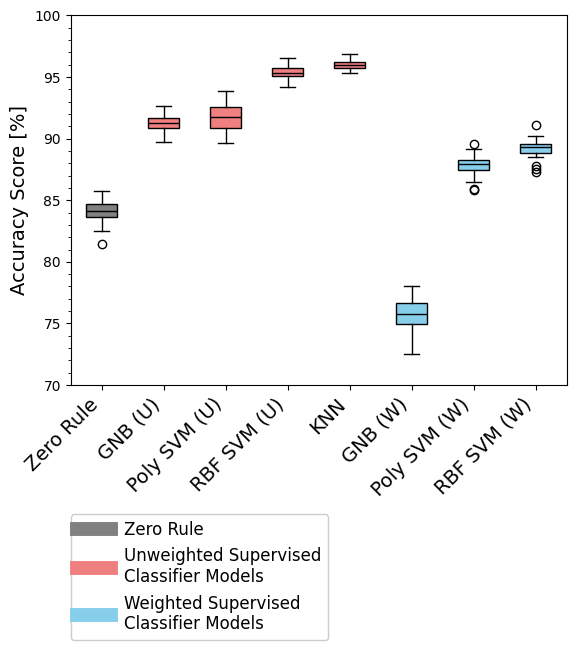

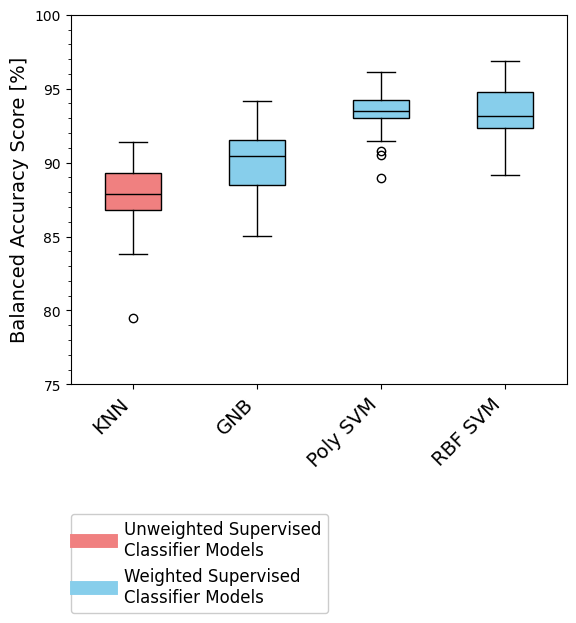

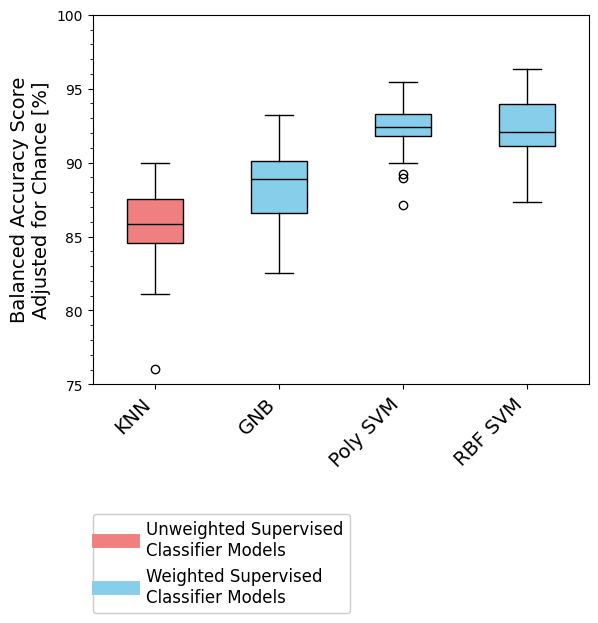

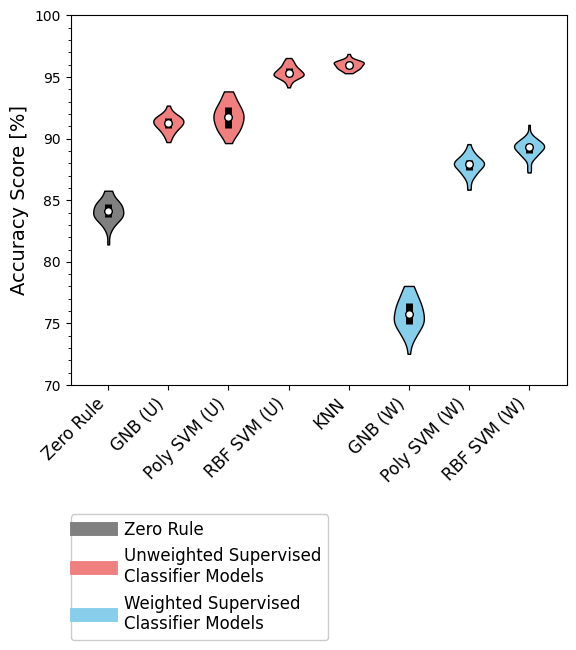

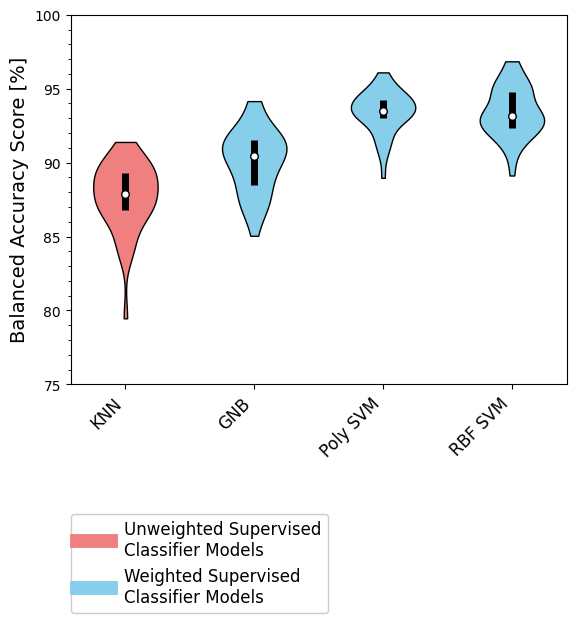

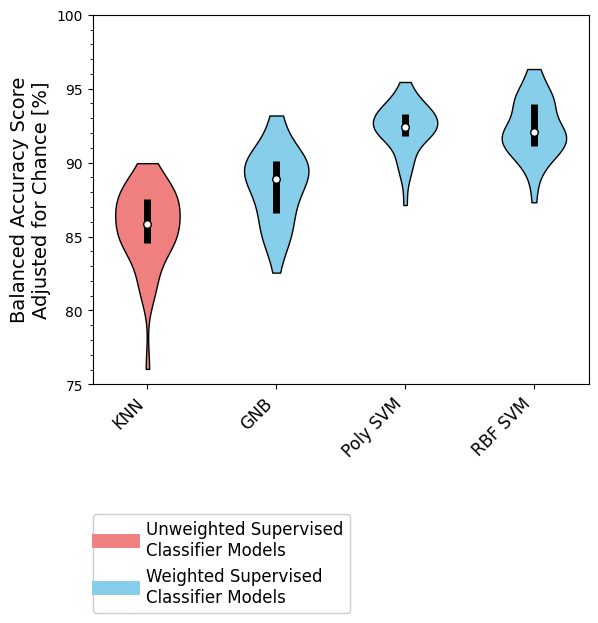

In [33]:
# Generate comparison plots for PAH-inclusive models

data_dict_with_pahs = {
    'raw': accuracies_dict_with_pahs,
    'balanced': balanced_accuracies_dict_with_pahs,
    'chance': chance_balanced_accuracies_dict_with_pahs
}

figsize = None  # Use default figure size

hide_unweighted = True  # Simplify plots by hiding unweighted models

# Generate plots for each combination of plot type and accuracy metric
for plot_choice in plot_type:
    for acc_type in data_dict_with_pahs.keys():
        # Configure y-axis label and data based on accuracy type
        if acc_type == 'raw':
            ylabel = 'Accuracy Score'
            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_with_pahs_acc
            colours_to_use = [zero_rule_colour] + boxplot_with_pahs_colors
            
            for x in accuracies_dict_with_pahs:
                data_to_use[x] = accuracies_dict_with_pahs[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy Score'
            data_to_use = balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy Score\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors

        # Optionally hide unweighted models
        if hide_unweighted and acc_type != 'raw':
            data_to_use = {x: data_to_use[x] for x in data_to_use if '(U)' not in x}
            colours_to_use = [model_colour(x) for x in data_to_use]

        # Simplify model names
        if acc_type != 'raw' and hide_unweighted:
             data_to_use = {x.replace(' (W)', ''): data_to_use[x] for x in data_to_use}

        # Create the plot
        fig, ax = plot_type[plot_choice](data_to_use,
                                         ylabel=f'{ylabel} [%]',
                                         colours=colours_to_use,
                                         figsize=figsize,
                                         savepath=f'{comparison_plots_output_folder}\\acc_comparison_with_pahs_{plot_choice}_{acc_type}.svg')
        
        # Set y-axis limits and ticks
        set_y_ticks(data_to_use, ax, major_ticks_interval=5,
                    minor_ticks_interval=1, rounding=2)
        
        # Add legend entries
        if acc_type == 'raw':
            ax.plot([None], [None], c=zero_rule_colour, label='Zero Rule', lw=10)

        for c in boxplot_colors_dict:
            if boxplot_colors_dict[c] in boxplot_with_pahs_colors:
                ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)
        
        if show_title:
            ax.set_title(f'Comparison of the {ylabel.replace("\n", " ")} of Assignment\nbetween Classifier Models Including PAHs' if show_title else None,
                         fontsize=16)

        # Position legend and save
        ax.legend(framealpha=1, bbox_to_anchor=(0, -.35), loc='upper left', borderaxespad=0, fontsize=12)
        fig.savefig(f'{comparison_plots_output_folder}\\acc_comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                    dpi=600, facecolor='#fff', bbox_inches='tight')

In [28]:
# Evaluate Brier Score Loss for probabilistic prediction quality
# Brier score measures the mean squared difference between predicted probabilities and actual outcomes
# Lower scores indicate better probability estimates (0 = perfect, 1 = worst possible)

brier_score_loss_dict = {model: [] for model in models_with_pahs_list}

repeats = 40

for n in range(repeats):

    for modeltype in [clf_models_with_pahs, clf_models_with_pahs_unweighted]:

        for model in modeltype:

            print(f'{n+1}/{repeats}\tTesting model: {model}')

            # Create random train-test split
            X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
            weights_rdm_train, weights_rdm_test = mlcf.train_test(X_with_pahs_3d, y_with_pahs, random_state=None)

            # Prepare fit arguments
            fit_args = dict(X=X_rdm_train, y=y_rdm_train)
            if weighted and modeltype == clf_models_with_pahs:
                fit_args['sample_weight'] = weights_rdm_train

            # Get probability predictions (required for Brier score)
            y_proba = modeltype[model].fit(**fit_args).predict_proba(X_rdm_test)

            # Calculate Brier score loss
            brier_score_loss_dict[model].append(brier_score_loss(y_rdm_test, y_proba, sample_weight=weights_rdm_test))

            print(f'\tBrier score loss = {brier_score_loss_dict[model][-1]}')

1/40	Testing model: GNB (W)
	Brier score loss = 0.19116998686863304
1/40	Testing model: Poly SVM (W)
	Brier score loss = 0.12107035812041518
1/40	Testing model: RBF SVM (W)
	Brier score loss = 0.14595323059170368
1/40	Testing model: GNB (U)
	Brier score loss = 0.5078851557334414
1/40	Testing model: Poly SVM (U)
	Brier score loss = 0.5780970792642591
1/40	Testing model: RBF SVM (U)
	Brier score loss = 0.4185279801376222
1/40	Testing model: KNN
	Brier score loss = 0.24072134795199626
2/40	Testing model: GNB (W)
	Brier score loss = 0.1460707304946659
2/40	Testing model: Poly SVM (W)
	Brier score loss = 0.1544553404238699
2/40	Testing model: RBF SVM (W)
	Brier score loss = 0.0946596471058396
2/40	Testing model: GNB (U)
	Brier score loss = 0.4742531542229433
2/40	Testing model: Poly SVM (U)
	Brier score loss = 0.6296839999550361
2/40	Testing model: RBF SVM (U)
	Brier score loss = 0.3576436867344676
2/40	Testing model: KNN
	Brier score loss = 0.19347053486792157
3/40	Testing model: GNB (W)
	

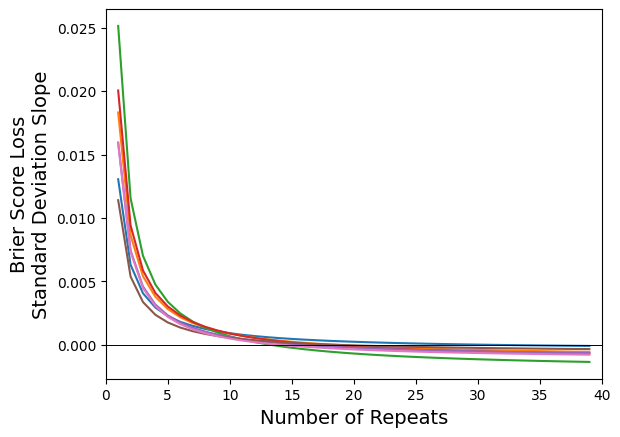

In [29]:
# Analyze convergence of Brier score loss standard deviation
# This determines if 40 repeats is sufficient for stable BSL estimates

SAVE = True

def fitting_func(x, a, c):
    """Hyperbolic function to fit BSL std deviation slope decay: y = c + a/x"""
    return c + (a / x)

curves_list = []

# Analyze each model individually
for model in brier_score_loss_dict.keys():
    fig, ax = plt.subplots()

    n_of_times = range(1, len(brier_score_loss_dict[model]) + 1)

    # Calculate standard deviation at each step
    step_wise_stds = [np.std(brier_score_loss_dict[model][:i]) for i in n_of_times]

    # Calculate rate of change of standard deviation
    y_axis = np.diff(step_wise_stds) / np.diff(n_of_times)

    ax.scatter(n_of_times[:-1], y_axis, marker='.', alpha=0.7)

    # Fit decay curve
    popt, pcov = curve_fit(fitting_func, n_of_times[:-1], y_axis)
    curves_list.append(fitting_func(np.array(n_of_times[:-1]), *popt))
    ax.plot(n_of_times[:-1], curves_list[-1], 'r--', label=f'$y={popt[1]:.4f}+\\frac{{{popt[0]:.4f}}}{{x}}$')

    if show_title:
        ax.set_title(f'{model}\nBrier Score Loss Standard Deviation Slope vs Number of Repeats', fontsize=14)
    ax.set_xlabel('Number of Repeats', fontsize=14)
    ax.set_ylabel('Brier Score Loss Standard Deviation Slope', fontsize=14)
    ax.set_xlim(0, len(brier_score_loss_dict[model]))

    ax.axhline(0, lw=.7, c='k')  # Reference line at zero slope

    if SAVE:
        fig.savefig(f'{comparison_plots_output_folder}\\bsl_std_vs_repeats\\bsl_std_slope_vs_repeats_{model.replace(" ", "_")}.png',
                    dpi=600, facecolor='#fff', bbox_inches='tight')

    plt.close()

# Create combined plot for all models
fig, ax = plt.subplots()
for curve in curves_list:
    ax.plot(range(1, len(brier_score_loss_dict[model])), curve)
if show_title:
    ax.set_title(f'All Models\nBrier Score Loss Standard Deviation Slope vs Number of Repeats', fontsize=14)
ax.set_xlabel('Number of Repeats',fontsize=14)
ax.set_ylabel('Brier Score Loss\nStandard Deviation Slope',fontsize=14)
ax.set_xlim(0, len(brier_score_loss_dict[model]))
ax.axhline(0, lw=.7, c='k')
if SAVE:
    fig.savefig(f'{comparison_plots_output_folder}\\bsl_std_vs_repeats\\bsl_std_slope_vs_repeats_all_models.png',
                dpi=600, facecolor='#fff', bbox_inches='tight')

In [30]:
# Summarize Brier Score Loss statistics and save to CSV

brier_score_loss_dict.keys()
brier_score_loss_df = pd.DataFrame({
    'model': [x for x in brier_score_loss_dict],
    'mean_bsl': [np.mean(brier_score_loss_dict[x]) for x in brier_score_loss_dict],
    'std_bsl': [np.std(brier_score_loss_dict[x]) for x in brier_score_loss_dict],
    'median_bsl': [np.median(brier_score_loss_dict[x]) for x in brier_score_loss_dict],
})
brier_score_loss_df.to_csv(f'{csv_folder}\\bsl.csv', index=False)

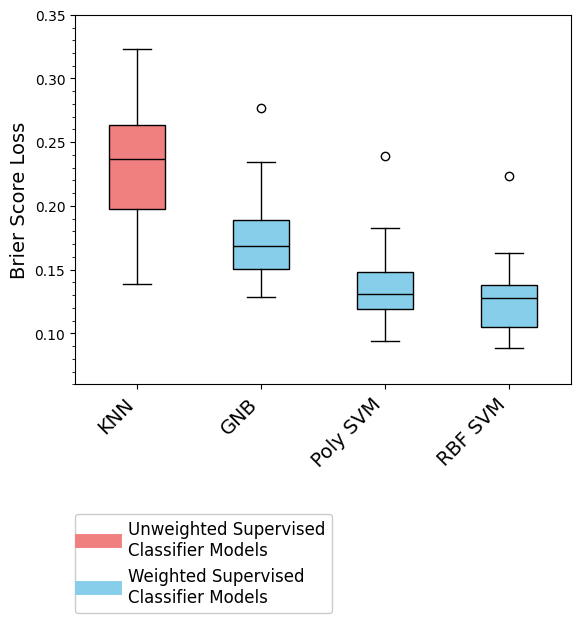

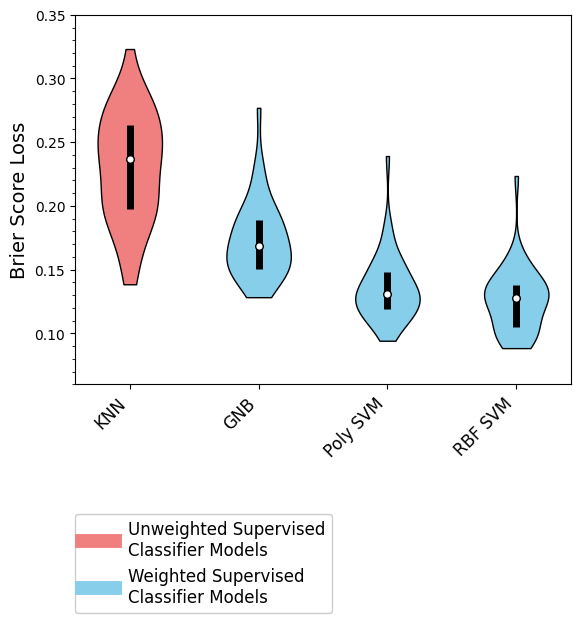

In [31]:
# Generate Brier Score Loss comparison plots

figsize = None  # Use default figure size

hide_unweighted = True  # Simplify visualization

for plot_choice in plot_type:
        
        # Prepare data (optionally hide unweighted models)
        data_to_use_bsl = {x: brier_score_loss_dict[x] for x in brier_score_loss_dict if '(U)' not in x} if hide_unweighted else brier_score_loss_dict

        # Assign colors based on model type
        colours_to_use_bsl = [model_colour(x) for x in data_to_use_bsl.keys()]

        # Simplify model names
        if hide_unweighted:
             data_to_use_bsl = {x.replace(' (W)', ''): data_to_use_bsl[x] for x in data_to_use_bsl}

        # Create plot
        fig, ax = plot_type[plot_choice](data_to_use_bsl,
                                         ylabel='Brier Score Loss',
                                         figsize=figsize,
                                         colours=colours_to_use_bsl)
        
        # Set y-axis limits appropriate for BSL (typically 0-0.35 range)
        mlcf.set_axis_ticks(data_to_use_bsl, ax, 'y', major_ticks_interval=0.05,
                            minor_ticks_interval=0.01, rounding=3,
                            upper_lim=0.35, lower_lim=0.06)

        if show_title:
            ax.set_title(f'Comparison of the Brier Score Loss\nbetween Classifier Models Including PAHs' if show_title else None,
                         fontsize=16)
            
        # Add legend for model categories
        for c in boxplot_colors_dict:
            if boxplot_colors_dict[c] in colours_to_use_bsl:
                ax.plot([None], [None], c=boxplot_colors_dict[c], label=c, lw=10)

        ax.legend(framealpha=1, bbox_to_anchor=(0, -.35), loc='upper left', borderaxespad=0, fontsize=12)
        fig.savefig(f'{comparison_plots_output_folder}\\bsl_comparison_with_pahs_{plot_choice}.svg',
                    dpi=600, facecolor='#fff', bbox_inches='tight')